<h3 style = "color:green">Introduction

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The rapid growth of electric vehicles (EVs) is reshaping the transportation industry worldwide. Understanding the factors that influence consumer adoption of EVs is essential for policymakers, manufacturers, and infrastructure providers. This dataset, containing 50,000 synthetic records, explores various demographic, behavioral, financial, transportation, and infrastructure-related characteristics that affect consumer decisions regarding electric vehicles. It captures relationships among commuting patterns, charging accessibility, environmental awareness, technology adoption, and EV-related concerns, providing valuable insights into the evolving electric mobility ecosystem.
</div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Note:</li>
<ul>
<ul>
<li>The word 'consumer' used in this project are people who currently own fuel/ICE vehicles and have NOT yet bought an EV. Each row represents a potential adopter — someone whose likelihood of switching to an EV is being studied.</li>
<li>The dataset is synthetically generated — so the 50,000 records don't represent real people. This project is focused on practicing EDA and further ML, not to  draw any  real-world conclusions from it.</li>
</ul>


<h3 style = "color:green">Objectives

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
The primary objective of this Exploratory Data Analysis (EDA) is to identify patterns, trends, and relationships that influence electric vehicle adoption and usage. Specifically, the analysis aims to:
<ul>
<li>Understand the demographic and behavioral characteristics of potential EV consumers.</li>
<li>Explore the impact of commuting habits on EV adoption preferences.</li>
<li>Analyze the relationship between charging infrastructure availability and consumer willingness to switch to EVs.</li>
<li>Examine how environmental awareness influences EV-related decisions.</li>
<li>Investigate the role of technology adoption and innovation acceptance in EV ownership.</li>
<li>Identify key concerns and barriers that may discourage consumers from adopting electric vehicles.</li>
<li>Discover meaningful correlations and trends that can support future predictive modeling and consumer behavior research.</li>
</ul>


In [79]:
import numpy as np
import pandas as pd
import polars as pl

from pandas import Series, DataFrame

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

<h3 style ="color:green">1. Getting Ready with Dataset

In [80]:
data = pl.read_csv('/home/kartika/Datasets/global_ev_adoption_behavior_2026.csv')
data = data.to_pandas()

In [81]:
data.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [82]:
data.tail()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
49995,27,26296.0,Bachelor,Urban,37.4,211.4,Sedan,0.0,314.8,10.0,...,9.9,6.6,8.9,5.1,7.8,9.3,1,High,162.5,37.5
49996,39,35476.0,Master,Suburban,30.5,158.3,Sedan,2.8,278.5,7.5,...,8.7,6.0,9.4,3.8,2.0,8.8,0,High,129.6,11.9
49997,30,20862.0,Master,Suburban,37.5,295.2,Sedan,0.0,358.4,7.7,...,7.3,6.6,4.5,5.2,1.3,5.9,0,High,218.3,52.8
49998,68,14694.0,Bachelor,Rural,40.3,256.5,Sedan,6.0,306.1,2.7,...,8.3,3.8,6.6,4.7,5.4,9.3,0,High,216.0,50.3
49999,48,28828.0,Bachelor,Suburban,28.5,192.6,Sedan,2.5,227.5,8.9,...,4.6,7.2,6.1,6.5,4.1,5.8,0,Medium,136.0,13.7


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [84]:
data.isnull().sum()

age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The columns education_level, charging_station_accessibility and ev_knowledge_score contain null values. This will be handled during their respective analysis.</div>

In [85]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No duplicate values.

<div>

<h3 style = "color:green">2. Univariate Analysis

<h3 style = "color:green">2. Age Distribution

In [86]:
data['age'].describe()

count    50000.000000
mean        44.996080
std         14.110844
min         21.000000
25%         33.000000
50%         45.000000
75%         57.000000
max         69.000000
Name: age, dtype: float64

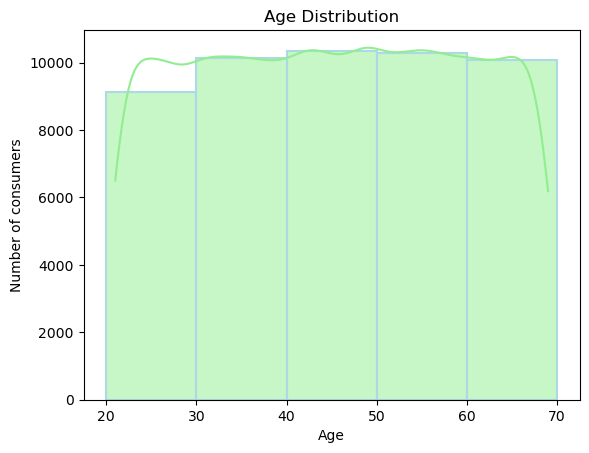

In [87]:
bins = [20, 30, 40, 50, 60, 70]
sns.histplot(data = data, x = 'age', bins = bins, kde = True, color = 'lightgreen', edgecolor = 'lightblue', linewidth = 1.5)


plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of consumers')
plt.xticks(bins)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">75% of the consumer age between 21-57. The age is normally distributed, meaning most of the consumers age is around 44. Fewer people are very young or very old.

<div>

<h3 style = "color:green">2.2 Annual Income of Adopters

In [88]:
data['annual_income'].describe()

count     50000.000000
mean      44311.869380
std       26109.170784
min        5104.000000
25%       25617.750000
50%       37891.000000
75%       56051.250000
max      250000.000000
Name: annual_income, dtype: float64

In [89]:
data['annual_income'].skew()

np.float64(1.6507888986092154)

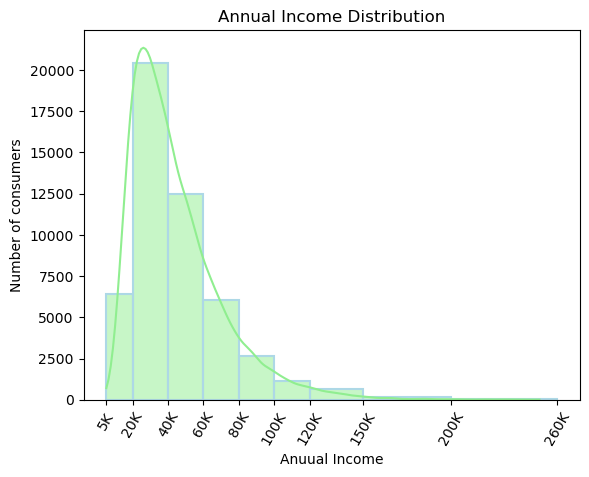

In [90]:
bins = [5000, 20000, 40000, 60000, 80000, 100000, 120000, 150000, 200000, 260000]
labels = ['5K', '20K', '40K', '60K', '80K', '100K', '120K', '150K', '200K', '260K']

sns.histplot(data = data, x = 'annual_income', bins = bins, kde = True, color = 'lightgreen', linewidth = 1.5, edgecolor = 'lightblue')

plt.title('Annual Income Distribution')
plt.xlabel('Anuual Income')
plt.ylabel('Number of consumers')
plt.xticks(bins, labels = labels, rotation = 60)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The annual income distribution is strongly positively skewed, implying majority of the consumer earns relatively low to moderate income, while a small percentage of consumer earns very high.</div>

<div>

<h3 style = "color:green">2.3 Education Level

In [91]:
data['education_level'].isnull().sum()

np.int64(500)

In [92]:
data[data['education_level'].isnull()]

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
250,48,50948.0,None,Suburban,29.0,189.0,Sedan,6.6,273.4,5.9,...,9.8,7.2,7.2,3.9,8.3,9.5,1,High,173.3,38.5
312,23,49881.0,None,Suburban,54.3,370.5,Hatchback,2.0,352.0,3.4,...,8.0,5.9,9.6,3.7,4.7,9.8,0,High,323.2,110.7
436,68,63018.0,None,Urban,25.7,174.4,Truck,7.6,183.5,6.4,...,8.0,5.7,9.1,5.5,4.2,10.0,0,High,173.4,51.9
579,59,78080.0,None,Rural,57.8,379.4,Sedan,5.5,448.6,7.5,...,4.4,6.6,6.9,6.3,7.3,5.4,1,Medium,277.6,40.8
764,66,85224.0,None,Suburban,36.2,226.7,Sedan,7.6,312.7,7.1,...,6.1,5.6,8.3,2.1,5.0,5.1,0,High,227.9,48.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49472,49,8595.0,None,Suburban,32.1,243.3,Sedan,6.0,205.0,2.3,...,6.1,6.3,5.3,6.0,5.8,6.5,1,Medium,214.1,68.0
49535,24,27970.0,None,Suburban,34.2,249.7,Hatchback,3.9,257.7,6.2,...,5.8,5.1,5.5,5.9,7.7,6.3,0,High,243.7,71.9
49738,48,42417.0,None,Rural,44.9,272.9,Hatchback,8.7,378.9,5.4,...,9.7,7.8,7.2,4.7,6.6,8.0,1,High,243.4,40.6
49835,37,40551.0,None,Suburban,42.4,286.0,SUV,4.4,310.0,7.9,...,8.0,4.6,8.6,5.1,5.2,NaN,1,High,234.4,46.6


In [93]:
data['education_level'] = data['education_level'].replace(r'^/s*$', np.nan, regex = True)

education_mode = data['education_level'].mode()[0]

data['education_level'] = data['education_level'].fillna(education_mode)

In [94]:
data['education_level'].value_counts()

education_level
Bachelor       22850
High School    12401
Master         12244
PhD             2505
Name: count, dtype: int64

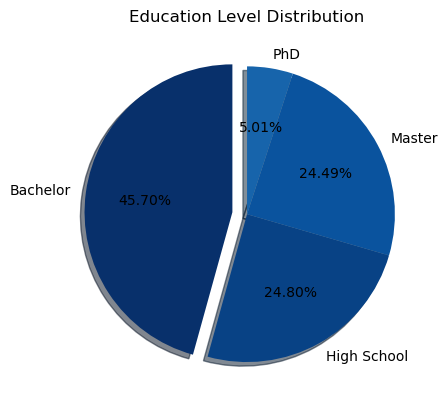

In [95]:
explode = [0.1, 0, 0, 0]
plt.pie(
    data['education_level'].value_counts().values,
    labels = data['education_level'].value_counts().index,
    explode = explode,
    colors = plt.cm.Blues(np.linspace(1,0.8,4)),
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
   
    )

plt.title('Education Level Distribution')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most consumers have an education level up to a bachelor's degree, accounting for 45% of the total. The number of consumers with a master's degree and those who completed high school is nearly the same. The relatively high proportion of bachelor's degree holders may be due to the missing values that were imputed using the mode of the education_level variable, which was "Bachelor's".

<div>

<h3 style = "color:green">2.4 Type of City

In [96]:
data['city_type'].value_counts()

city_type
Urban       22645
Suburban    17348
Rural       10007
Name: count, dtype: int64

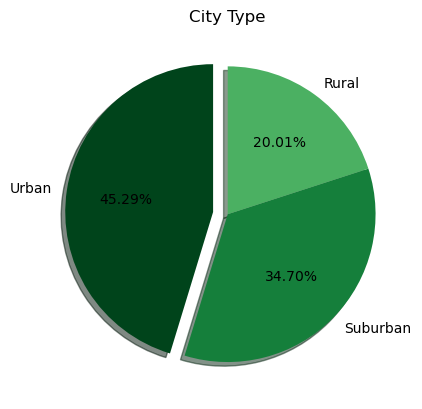

In [97]:
explode = [0.1, 0, 0]
plt.pie(
    data['city_type'].value_counts().values,
    labels = data['city_type'].value_counts().index,
    explode = explode,
    colors = plt.cm.Greens(np.linspace(1,0.4,4)),
    autopct = '%1.2f%%',
    shadow = True,
    startangle = 90
   
    )

plt.title('City Type')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the consumers reside in urban/cities, which accounts for 45% of the total. Moderate number of consumers reside in suburban areas, around the cities.

<div>

<h3 style = "color:green">2.5 Daily Commute  and Weekly Travel Distance

In [98]:
data['daily_commute_km'].describe()

count    50000.000000
mean        35.169358
std         14.736042
min          5.000000
25%         25.000000
50%         35.100000
75%         45.200000
max         97.900000
Name: daily_commute_km, dtype: float64

In [99]:
data['daily_commute_km'].skew()

np.float64(0.12723130350867326)

In [100]:
data['weekly_travel_distance_km'].describe()

count    50000.000000
mean       228.727200
std        101.147254
min         25.000000
25%        157.700000
50%        224.100000
75%        294.500000
max        732.300000
Name: weekly_travel_distance_km, dtype: float64

In [101]:
data['weekly_travel_distance_km'].skew()

np.float64(0.31725945174586445)

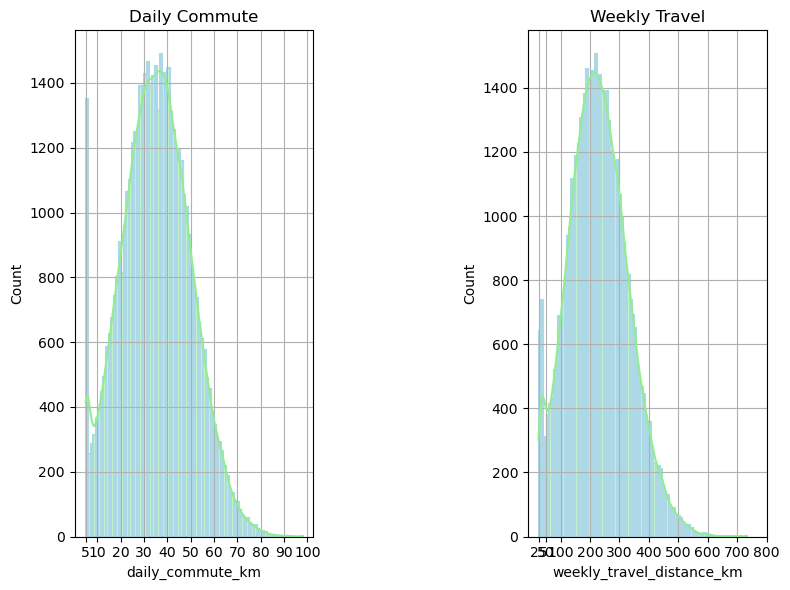

In [102]:
daily_bins = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

weekly_bins = [25, 50, 100, 200, 300, 400, 500, 600, 700, 800]

fig, ax = plt.subplots(1,2, figsize = (8,6))

sns.histplot(
    data = data,
    x = 'daily_commute_km',
    kde = True,
    color = 'lightgreen',
    linewidth = 1.5,
    edgecolor = 'lightblue',
    ax = ax[0]
)
ax[0].set_title('Daily Commute')
ax[0].set_xticks(daily_bins)
ax[0].grid(True)

sns.histplot(
    data = data,
    x = 'weekly_travel_distance_km',
    kde = True,
    color = 'lightgreen',
    linewidth = 1.5,
    edgecolor = 'lightblue',
    ax = ax[1]
)
ax[1].set_title('Weekly Travel')
ax[1].set_xticks(weekly_bins)
ax[1].grid(True)


plt.tight_layout()
plt.subplots_adjust(wspace = 0.9)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li> Most consumers commute between 20–45 km per day, with the peak around 35 km. The distribution is slightly right-skewed, indicating that while long commutes are uncommon, some consumers travel significantly farther than the average. There is also a noticeable concentration of observations near 5 km, suggesting a group of consumers with very short commutes.</li>
<li>
 Most consumers travel between 25-300 km weekly, with the peak around 228 km. The distribution is also slightly right-skewed. This distribution also contain concentration of observations near low travel distance that is around 25-50 km.
 </li>
 </ul>
 </div>

<div>

<h3 style = "color:green">2.6 Current Vehicle Type


In [103]:
data['current_vehicle_type'].value_counts()

current_vehicle_type
Sedan        17512
SUV          14933
Hatchback    12561
Truck         4994
Name: count, dtype: int64

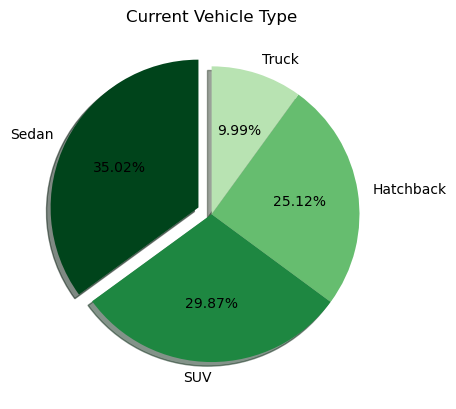

In [104]:
plt.pie(data['current_vehicle_type'].value_counts().values,
        labels = data['current_vehicle_type'].value_counts().index,
        colors = plt.cm.Greens(np.linspace(1,0.3,4)),
        startangle = 90,
        shadow = True,
        explode = [0.1, 0, 0, 0],
        autopct = '%1.2f%%')

plt.title('Current Vehicle Type')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Sedans dominate at 35%, followed by SUVs(30%) and hatchbacks (25%), with trucks beign the smallest segment at just 10%.

<dvi>

<h3 style = "color:green">2.7 Current Vehicle Age

In [105]:
data['vehicle_age_years'].describe()

count    50000.000000
mean         6.012842
std          2.947132
min          0.000000
25%          3.900000
50%          6.000000
75%          8.000000
max         20.000000
Name: vehicle_age_years, dtype: float64

In [106]:
data['vehicle_age_years'].skew()

np.float64(0.12338224190281258)

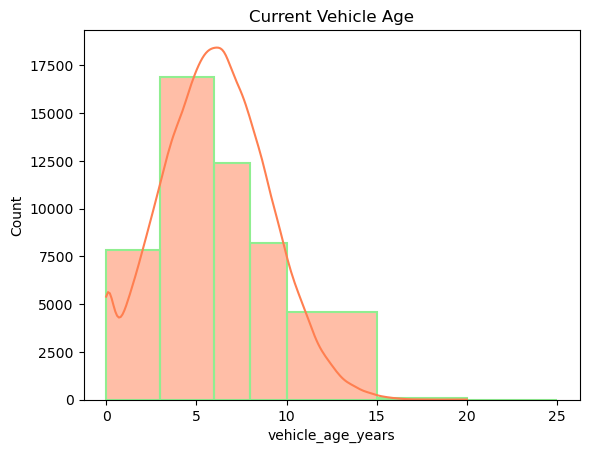

In [107]:
bins = [0, 3, 6, 8, 10, 15, 20, 25]

sns.histplot(
    data = data,
    x = 'vehicle_age_years',
    bins = bins,
    color = 'coral',
    linewidth = 1.5,
    edgecolor = 'lightgreen',
    kde = True)



plt.title('Current Vehicle Age')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> Most of the consumers have vehicle of age 6-8 years, with peak at 6 years. There are also few consumers having very new and very old vehicles.

<div>

<h3 style = "color:green">2.8 Monthly Fuel Expense

In [108]:
data['fuel_expense_per_month'].describe()

count    50000.000000
mean       295.169608
std        130.178552
min        -99.700000
25%        205.200000
50%        294.800000
75%        383.000000
max        862.000000
Name: fuel_expense_per_month, dtype: float64

In [109]:
data.loc[data['fuel_expense_per_month']<0, 'fuel_expense_per_month'] = np.nan

In [110]:
data['fuel_expense_per_month'] = data.groupby('current_vehicle_type')['fuel_expense_per_month'].transform(lambda x: x.fillna(x.median()))

In [111]:
data['fuel_expense_per_month'].describe()

count    50000.000000
mean       296.874814
std        128.089957
min         -0.000000
25%        207.100000
50%        295.800000
75%        383.000000
max        862.000000
Name: fuel_expense_per_month, dtype: float64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">271 records(0.54%) have negative monthly fuel expense, likely an artifact of synthetic data generation. Since, fuel expense cannot be negative for non-EV vechile, these are treated as invalid values. These are replace with nan and imputed with median fuel expense based on vechile type.

In [112]:
data['fuel_expense_per_month'].skew()

np.float64(0.15033246899066277)

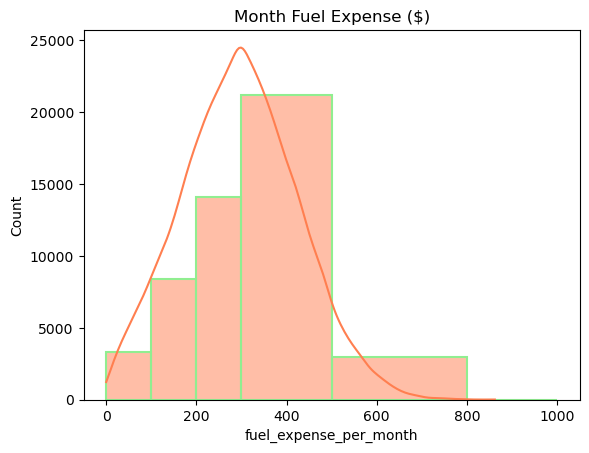

In [113]:
bins = [0, 100, 200, 300, 500, 800, 1000]

sns.histplot(
    data= data,
    x = 'fuel_expense_per_month',
    bins = bins,
    color = 'coral',
    linewidth = 1.5,
    edgecolor = 'lightgreen',
    kde = True,
)

plt.title('Month Fuel Expense ($)')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the vehicle fuel expense is in range 168$ - 424$. The distribution is positively skewed, indicating there are few vehicle with very high fuel expense.

<div>

<h3 style = "color:green">2.9 Charging Station Accessibility

In [114]:
data['charging_station_accessibility'].isnull().sum()

np.int64(500)

In [115]:
data.loc[data['charging_station_accessibility'].isnull(),['charging_station_accessibility']] = np.nan

In [116]:
data['charging_station_accessibility'] = data['charging_station_accessibility'].fillna(data['charging_station_accessibility'].mode())

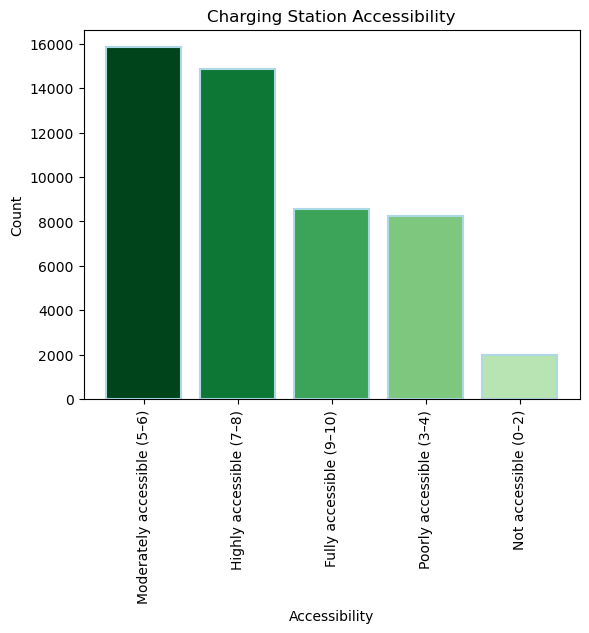

In [117]:
bins = [-0.1, 2, 4, 6, 8, 10]
labels = [
    "Not accessible (0–2)",
    "Poorly accessible (3–4)",
    "Moderately accessible (5–6)",
    "Highly accessible (7–8)",
    "Fully accessible (9–10)"
]

data["accessibility_label"] = pd.cut(
    data["charging_station_accessibility"],
    bins=bins,
    labels=labels
)


plt.bar(
    height= data['accessibility_label'].value_counts().values,
    x = data['accessibility_label'].value_counts().index,
    color = plt.cm.Greens(np.linspace(1,0.3,5)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)

plt.title('Charging Station Accessibility')
plt.xlabel('Accessibility')
plt.ylabel('Count')
plt.xticks(labels, rotation = 90)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> Most of the charging stations have good accessibility. Moderate Accessibility is most common followed by highly and fully accessiblity. There are few charging stations with poor and no accessibility.

<div>

<h3 style = "color:green">2.10 Availability of Home Charging Station

In [118]:
data.loc[:10, ['home_charging_available']]

,home_charging_available
0,1
1,1
2,1
3,0
4,0
5,0
6,0
7,1
8,1
9,1


In [119]:
data['home_charging_available'] = data['home_charging_available'].replace({1:'Yes', 0:'No'})

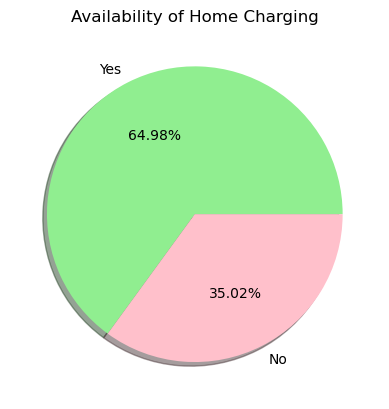

In [120]:
plt.pie(
    data['home_charging_available'].value_counts().values,
    labels = data['home_charging_available'].value_counts().index,
    colors = ['lightgreen', 'pink'],
    shadow = True,
    autopct = "%1.2f%%"
)

plt.title('Availability of Home Charging')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Nearly, majority of the consumers have home charging availability.

<div>

<h3 style = "color:green">2.11 EV Electricity Cost

In [121]:
data['monthly_charging_cost'] = data['electricity_cost_per_kwh'] * data['monthly_energy_consumption_kwh']
data['monthly_charging_cost'].describe()

count    50000.000000
mean        40.237774
std         24.952036
min          1.422000
25%         21.594500
50%         35.260000
75%         54.091000
max        200.340000
Name: monthly_charging_cost, dtype: float64

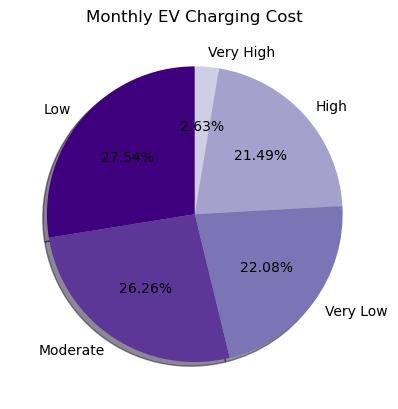

In [122]:
bins = [0, 20, 35, 55, 100, 200]
labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

data['monthly_charging_expense'] = pd.cut(data['monthly_charging_cost'], bins = bins, labels = labels)

plt.pie(
    data['monthly_charging_expense'].value_counts().values,
    labels = data['monthly_charging_expense'].value_counts().index,
    colors = plt.cm.Purples(np.linspace(1, 0.3, 5)),
    shadow = True,
    startangle = 90,
    autopct = "%1.2f%%"
    )


plt.title('Monthly EV Charging Cost')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">For more than majority of the consumers, EV charging costs from very low to moderate, while for one-fourth of the consumers charging costs high to very high.

<div>

<h3 style = "color:green">2.12 EV Knowledge

In [123]:
data['ev_knowledge_score'].describe()

count    49500.000000
mean         6.755673
std          1.945842
min          1.000000
25%          5.300000
50%          7.000000
75%          8.300000
max         10.000000
Name: ev_knowledge_score, dtype: float64

In [124]:

data['ev_knowledge_score'] = data['ev_knowledge_score'].fillna(data['ev_knowledge_score'].mode()[0])


In [125]:
data['ev_knowledge_score'].describe()

count    50000.000000
mean         6.788116
std          1.962815
min          1.000000
25%          5.400000
50%          7.000000
75%          8.300000
max         10.000000
Name: ev_knowledge_score, dtype: float64

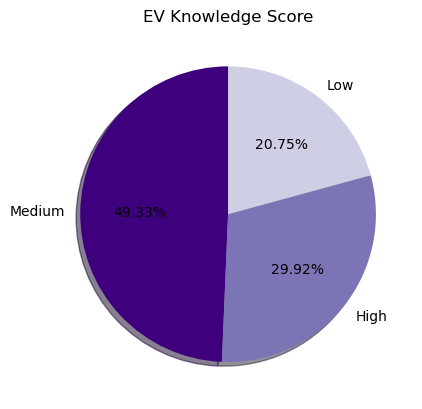

In [126]:
bins = [1, 5, 8, 10]
labels = ['Low', 'Medium', 'High']

data['ev_knowledge'] = pd.cut(data['ev_knowledge_score'], bins = bins , labels = labels)

plt.pie(
    data['ev_knowledge'].value_counts().values,
    labels = data['ev_knowledge'].value_counts().index,
    autopct ="%1.2f%%",
    shadow = True,
    colors = plt.cm.Purples(np.linspace(1, 0.3, 3)),
    startangle = 90,
)

plt.title('EV Knowledge Score'
)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Majority of the consumers have medium to high knowledge about EVs, while around 20% of the consumers have low knowledge.

<div>

<h3 style = "color:green">2.13 Technolog Affinity

In [127]:
data['technology_affinity_score'].describe()

count    50000.000000
mean         6.721914
std          1.990730
min          2.000000
25%          5.200000
50%          6.700000
75%          8.500000
max         10.000000
Name: technology_affinity_score, dtype: float64

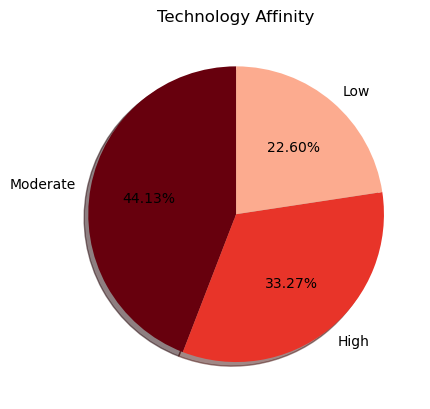

In [128]:
bins = [2, 5, 8, 10]
labels = ['Low', 'Moderate', 'High']

data['technology_affinity'] = pd.cut(data['technology_affinity_score'], bins = bins , labels = labels)

plt.pie(
    data['technology_affinity'].value_counts().values,
    labels = data['technology_affinity'].value_counts().index,
    autopct = "%1.2f%%",
    shadow = True,
    startangle = 90,
    colors = plt.cm.Reds(np.linspace(1,0.3,3))
)

plt.title(
    'Technology Affinity'
)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">More than one-third of the consumers have high technology affinity.

<div>

<h3 style = "color:green">2.14 Previous EV Experience

In [129]:
data['previous_ev_experience']

0        0
1        1
2        0
3        0
4        0
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: previous_ev_experience, Length: 50000, dtype: int64

In [130]:
data['previous_ev_experience'] = data['previous_ev_experience'].replace({0:'No', 1:'Yes'})


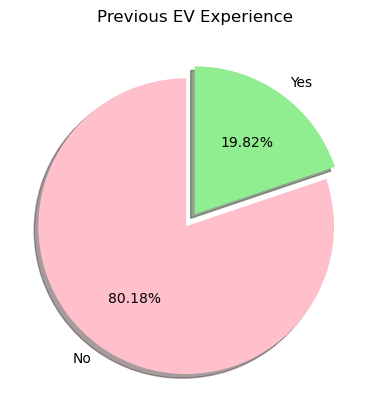

In [131]:
plt.pie(
    data['previous_ev_experience'].value_counts().values,
    labels = data['previous_ev_experience'].value_counts().index,
    autopct = "%1.2f%%",
    startangle = 90,
    shadow = True,
    colors = ['pink', 'lightgreen'],
    explode = [0.1, 0]
)

plt.title(
    'Previous EV Experience'
)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Around 80% of the consumers have no prior ev experience.

<div>

<h3 style = "color:green">2.15 EV Adoption Likelihood (Target Variable)

In [132]:
data['ev_adoption_likelihood'].value_counts()

ev_adoption_likelihood
High      29670
Medium    12078
Low        8252
Name: count, dtype: int64

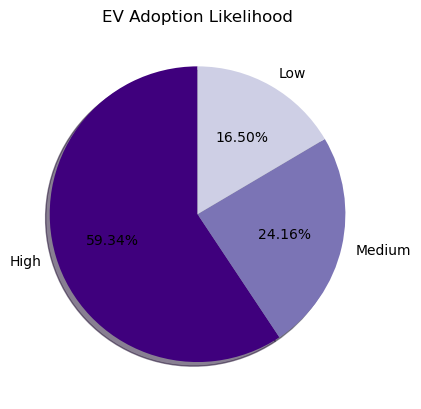

In [133]:
plt.pie(
    data['ev_adoption_likelihood'].value_counts().values,
    labels = data['ev_adoption_likelihood'].value_counts().index,
    autopct = "%1.2f%%",
    startangle = 90,
    shadow = True,
    colors = plt.cm.Purples(np.linspace(1, 0.3, 3))
)

plt.title('EV Adoption Likelihood')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Nearly 60% of the consumers have high likelihood to adopt ev. 

<div>

<div>

<h3 style ="color:green">3. Bivariate and Multi-Variate Analysis

<h3 style = "color:green">3.1 Annual Income vs EV Adoption Likelihood

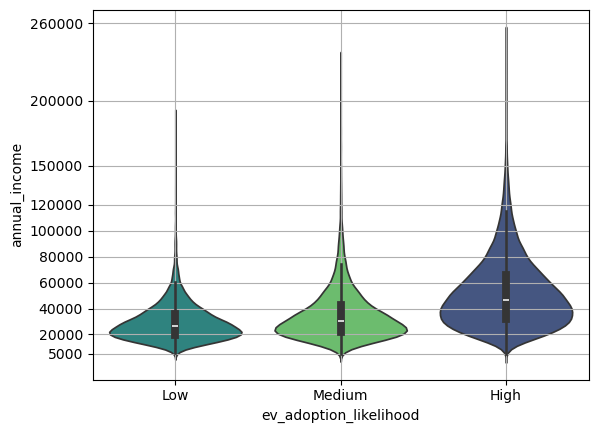

In [134]:

bins = [5000, 20000, 40000, 60000, 80000, 100000, 120000, 150000, 200000, 260000]
labels = ['5K', '20K', '40K', '60K', '80K', '100K', '120K', '150K', '200K', '260K']

sns.violinplot(
    data = data,
    x = 'ev_adoption_likelihood',
    y = 'annual_income',
    hue = 'ev_adoption_likelihood',
    order = ['Low', 'Medium', 'High'],
    palette = 'viridis',
    inner = 'box'
)

plt.grid(True)
plt.yticks(bins)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> Consumers having comparatively high annual income tends to have high EV adoption likelihood.

<div>

<h3 style = "color:green">3.2 City Type vs EV Adoption Likelihood

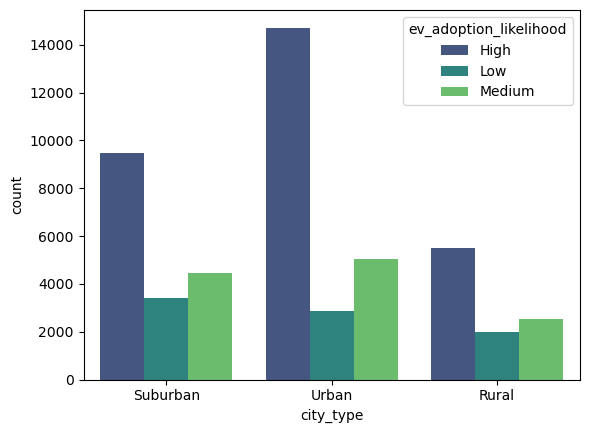

In [135]:
sns.countplot(
    data = data,
    x = 'city_type',
    hue = 'ev_adoption_likelihood',
    palette = 'viridis'
    
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Urban consumers have high ev adoption likelihood. Suburban region also have moderate number of high ev adoption likelihood.

<div>

<h3 style = "color:green">3.3 Daily Commute and Weekly Travel Distance vs EV Adoption Likelihood

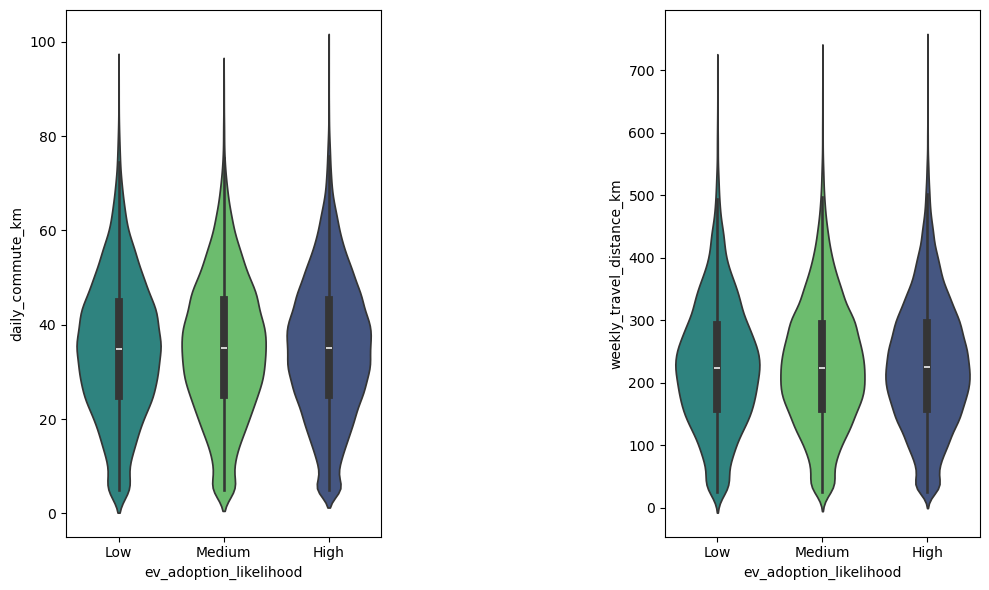

In [136]:

fig, ax = plt.subplots(1,2, figsize = (10,6))

sns.violinplot(
    data = data,
    x = 'ev_adoption_likelihood',
    y = 'daily_commute_km',
    hue = 'ev_adoption_likelihood',
    order = ['Low', 'Medium', 'High'],
    palette = 'viridis',
    inner = 'box',
    ax = ax[0]
)

sns.violinplot(
    data = data,
    x = 'ev_adoption_likelihood',
    y = 'weekly_travel_distance_km',
    hue = 'ev_adoption_likelihood',
    order = ['Low', 'Medium', 'High'],
    palette = 'viridis',
    inner = 'box',
    ax = ax[1]
)




plt.tight_layout()
plt.subplots_adjust(wspace = 0.9)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Although the central tendency in both plots differe, the overall dispersion in consistent among consumers with low, medium and high ev adoption likelihood. This indicates neither daily commute nor weekly travel distance is strongly seperating the groups.

<div>

<h3 style = "color:green">3.4 Vehicle Types and Their Age vs EV Adoption Likelihood

<h4 style = "color:green">3.4.1 Vehicle Types vs EV Adoption Likelihood

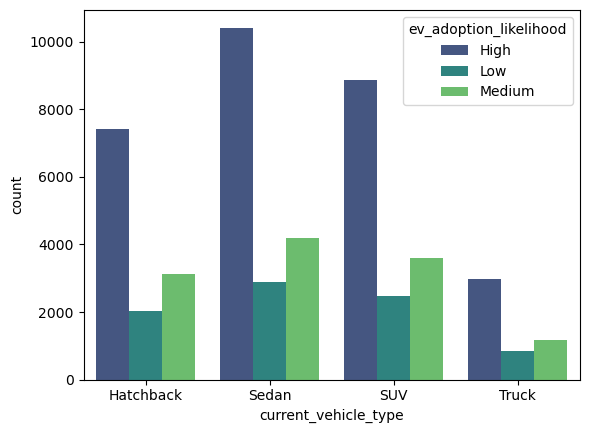

In [137]:
sns.countplot(
    data = data,
    x = 'current_vehicle_type',
    hue = 'ev_adoption_likelihood',
    palette = 'viridis'
)

plt.show()

<h4 style = "color:green">3.4.2 Vehicle Types and Their Age vs EV Adoption Likelihood

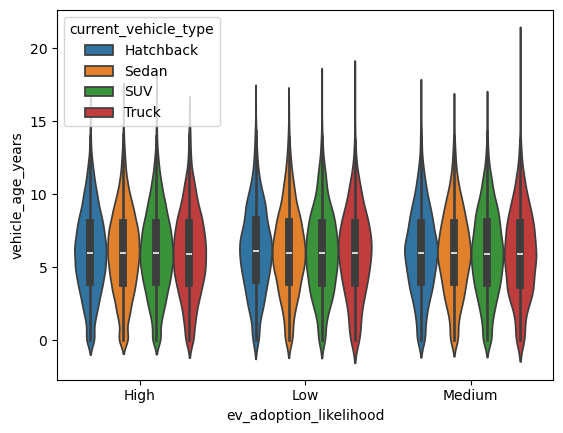

In [138]:
sns.violinplot(
    data = data,
    x = 'ev_adoption_likelihood',
    y = 'vehicle_age_years',
    hue = 'current_vehicle_type',
    split = False
    
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Vehicle age distribution are very similar across all EV adoption likelihood groups (High, Medium, Low) and across all vehicle types(Hatchback, Sedan, SUV, Truck). This indicates, neither vehicle age nor its interaction with vehicle type has a strong relationship with consumer's likelihood of adopting EVs.

<div>

<h3 style = "color:green">3.5 Vehicle Types and Their Monthly Fuel Expense vs EV Adoption Likelihood

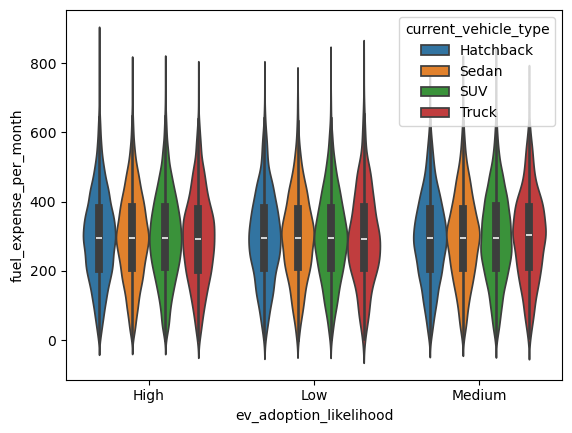

In [139]:
sns.violinplot(
    data = data,
    x = 'ev_adoption_likelihood',
    y = 'fuel_expense_per_month',
    hue = 'current_vehicle_type',
    split = False,

)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Monthly fuel expense distribution are very similar across all EV adoption likelihood groups (High, Medium, Low) and across all vehicle types(Hatchback, Sedan, SUV, Truck). This indicates, neither monthly fuel expense nor its interaction with vehicle type has a strong relationship with consumer's likelihood of adopting EVs.

<div>

<h3 style = "color:green">3.6 Monthly Charging Expense vs EV Adoption Likelihood

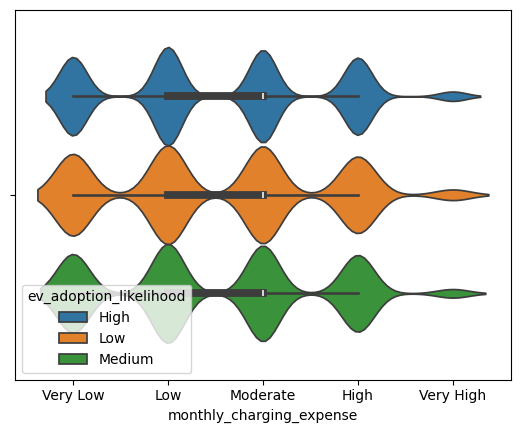

In [140]:
sns.violinplot(
    data = data,
    x = 'monthly_charging_expense',
    hue = 'ev_adoption_likelihood',
    

)

plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Monthly Charging Expense distribution are very similar across all EV adoption likelihood groups (High, Medium, Low). This indicats, monthly charging expense has no strong relationship with consumer's likelihood of adopting EVs.

<div>

<h3 style = "color:green">3.7 Charing Station Accessibility vs EV Adoption Likelihood

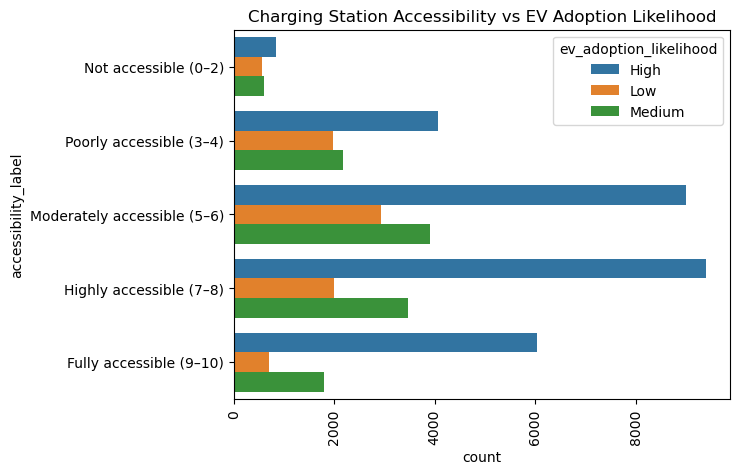

In [144]:
sns.countplot(
    data= data,
    y = 'accessibility_label',
    hue = 'ev_adoption_likelihood',    
)

plt.title('Charging Station Accessibility vs EV Adoption Likelihood')
plt.xticks(rotation = 90)
plt.show()                                                                                          

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Consumers with moderate to full charging station accessibility show high likelihood to adopt ev.

<div>

<h3 style ="color:green">3.8 E 

In [ ]:
data.columns

Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost',
       'accessibility_label', 'monthly_charging_expense', 'ev_knowledge',
       'technology_affinity'],
      dtype='object')